# Mass Balance — Aral Sea (GRACE mascon)

Sanity check of the method on a region with a large, well-known storage
trend.  The residual $P - ET - \Delta S$ is the **net outflow** (river inflow
minus lake/irrigation loss is what ΔS already integrates, so a negative
residual means P − ET is smaller than the observed storage change and vice
versa).  Only blocks that overlap the historical lake bounding box by at least
`MIN_OVERLAP` are used, so the domain is not dominated by desert far from
the lake.  Pipeline: `src/` modules (WaPOR is Africa-only and is skipped).

## 1 — Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import IFrame, display
from shapely.geometry import box as shapely_box

from src.gee_utils import ee_init
from src.grace_blocks import (discover_blocks, describe, block_area_m2, blocks_union,
                              block_tws, domain_tws, ee_geometry, block_map)
from src.et_products import compute_et_products, et_wide, summarize
from src.precip import compute_chirps
from src.balance import assemble_balance, monthly_climatology, write_outputs
from src import balance_plots as bp

GRACE_NC = Path("../data/grace_subsaharan_out/GRCTellus.JPL.200204_202507.GLO.RL06.3M.MSCNv04CRI.nc")
assert GRACE_NC.exists()

# Historical (pre-1960) Aral Sea extent
ARAL_LAT_MIN, ARAL_LAT_MAX = 43.0, 46.8
ARAL_LON_MIN, ARAL_LON_MAX = 58.2, 61.5
aral_poly = shapely_box(ARAL_LON_MIN, ARAL_LAT_MIN, ARAL_LON_MAX, ARAL_LAT_MAX)
MIN_OVERLAP = 0.10          # keep blocks covering ≥ 10 % of the bbox

START = "2002-04-01"
END = (pd.Timestamp.today().normalize() + pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")
GEOM_TAG = "grace_aral_sea"
FIG_DIR = Path("../figures/ET comparison") / GEOM_TAG
FIG_DIR.mkdir(parents=True, exist_ok=True)
RUN_EE = True
DOMAIN_LABEL = "Aral Sea blocks"
print(f"Window : {START} → {END}")

Window : 2002-04-01 → 2026-10-01


## 2 — Discover GRACE mascon blocks covering the Aral Sea

In [2]:
blocks = discover_blocks(GRACE_NC, ref_geom=aral_poly, pad_deg=6.0)
print(f"Discovered {len(blocks)} blocks; those intersecting the Aral bbox:")
for b in [b for b in blocks if b["intersects_ref"]]:
    print(f"  {describe(b)}  frac_bbox={b['frac_ref']:.1%}")
USE_BLOCKS = [b for b in blocks if b["frac_ref"] >= MIN_OVERLAP]
print(f"\nSelected (≥ {MIN_OVERLAP:.0%} overlap): {[b['block_id'] for b in USE_BLOCKS]}  "
      f"covering {sum(b['frac_ref'] for b in USE_BLOCKS):.0%} of the bbox")
m = block_map(blocks, {"#1b9e77": USE_BLOCKS}, center=((ARAL_LAT_MIN + ARAL_LAT_MAX) / 2, (ARAL_LON_MIN + ARAL_LON_MAX) / 2),
              zoom_start=6)
import folium
folium.Rectangle(bounds=[[ARAL_LAT_MIN, ARAL_LON_MIN], [ARAL_LAT_MAX, ARAL_LON_MAX]], color="#8c2d04", weight=3,
                 fill=False, tooltip="Aral Sea bbox (historical)").add_to(m)
map_path = FIG_DIR / "aral_sea_grace_map.html"; m.save(str(map_path))
IFrame(src=str(map_path), width=800, height=500)

Discovered 32 blocks; those intersecting the Aral bbox:
  B011 (NW)  lon 54.00–58.50  lat 46.50–49.50  54 px  frac_bbox=0.7%
  B012 (NE)  lon 58.50–63.00  lat 46.50–49.50  54 px  frac_bbox=7.2%
  B015 (NW)  lon 55.50–60.00  lat 43.50–46.50  54 px  frac_bbox=43.1%
  B016 (NE)  lon 60.00–64.50  lat 43.50–46.50  54 px  frac_bbox=35.9%
  B020 (SW)  lon 56.50–60.50  lat 40.50–43.50  48 px  frac_bbox=9.2%
  B021 (SE)  lon 60.50–64.50  lat 40.50–43.50  48 px  frac_bbox=4.0%

Selected (≥ 10% overlap): ['B015', 'B016']  covering 79% of the bbox


## 3 — Earth Engine geometry + area

In [3]:
ee_init()
block_geom = ee_geometry(USE_BLOCKS)          # one polygon per block
block_union = blocks_union(USE_BLOCKS)        # shapely, for GLEAM
block_area_m2_ = sum(block_area_m2(b) for b in USE_BLOCKS)
ee_area = float(block_geom.area(maxError=1).getInfo())
print(f"Domain area: {block_area_m2_/1e6:,.0f} km² (geodesic)   EE: {ee_area/1e6:,.0f} km²")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Domain area: 236,496 km² (geodesic)   EE: 235,971 km²


## 4 — Monthly ET

MOD16A2GF_v61     : 285 valid months (2002-04-01 → 2025-12-01)


PML_v2_landET     : 273 valid months (2002-04-01 → 2024-12-01)


TerraClimate_aet  : 273 valid months (2002-04-01 → 2024-12-01)


FLDAS_Evap        : 293 valid months (2002-04-01 → 2026-08-01)


ERA5Land_totalET  : 293 valid months (2002-04-01 → 2026-08-01)


USGS_SSEBop       : 233 valid months (2003-01-01 → 2022-05-01)


GLEAM_v42a        : 273 valid months
Saved: ../figures/ET comparison/grace_aral_sea/et_monthly.csv  (2027 rows)


,first,last,n,mean_mm,coverage
dataset,,,,,
ERA5Land_totalET,2002-04-01,2026-08-01,293,23.0,1.00
FLDAS_Evap,2002-04-01,2026-08-01,293,11.2,0.97
GLEAM_v42a,2002-04-01,2024-12-01,273,14.1,0.92
MOD16A2GF_v61,2002-04-01,2025-12-01,285,13.9,0.51
PML_v2_landET,2002-04-01,2024-12-01,273,9.8,0.87
TerraClimate_aet,2002-04-01,2024-12-01,273,10.3,1.00
USGS_SSEBop,2003-01-01,2022-05-01,233,8.8,1.00


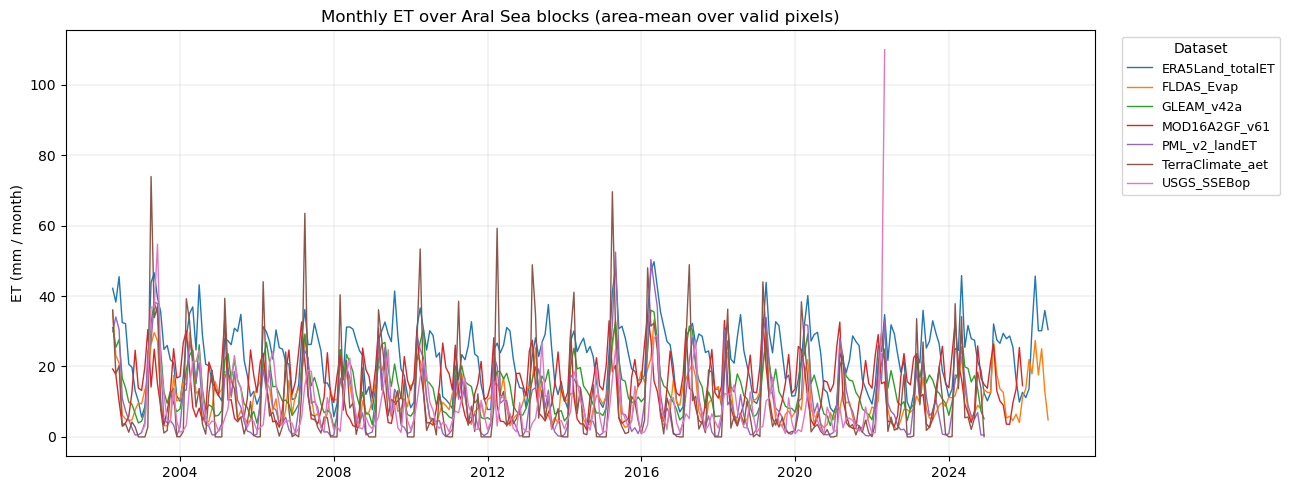

In [4]:
df_et = compute_et_products(block_geom, block_area_m2_, START, END,
                            csv_path=FIG_DIR / "et_monthly.csv", run=RUN_EE,
                            gleam_geom=block_union, africa=False)
display(summarize(df_et))
et_mm_wide = et_wide(df_et, "et_mm_mean")
bp.plot_et_products(et_mm_wide, f"Monthly ET over {DOMAIN_LABEL} (area-mean over valid pixels)",
                    save=FIG_DIR / "et_products.png"); plt.show()

## 5 — CHIRPS precipitation

In [5]:
df_chirps = compute_chirps(block_geom, block_area_m2_, START, END,
                           csv_path=FIG_DIR / "chirps_monthly.csv", run=RUN_EE)

CHIRPS: 293 valid months (2002-04-01 → 2026-08-01)
Saved: ../figures/ET comparison/grace_aral_sea/chirps_monthly.csv  (294 rows)


## GRACE TWS over the domain

Block TWS comes from the **local JPL netCDF** (all pixels in a mascon share one
series), labelled by the midpoint of each solution's `time_bounds`.  The earlier
Earth Engine reduction labelled solutions by the day before their period and
put ~90 % of months one month early.

GRACE solutions: 246  (2002-04-01 → 2025-07-01)


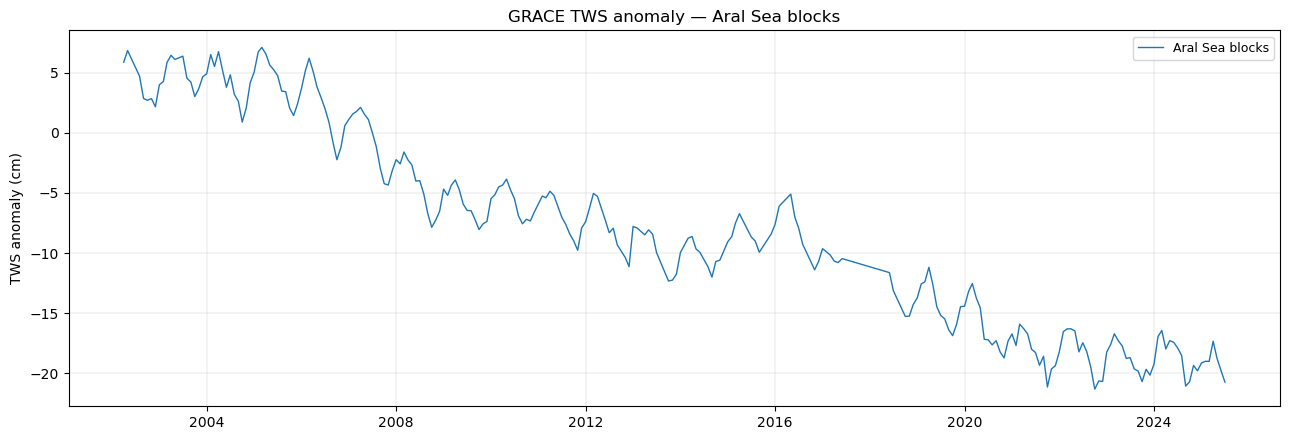

In [6]:
df_tws = domain_tws(GRACE_NC, USE_BLOCKS)
df_tws.to_csv(FIG_DIR / "grace_monthly.csv")
print(f"GRACE solutions: {len(df_tws)}  ({df_tws.index.min().date()} → {df_tws.index.max().date()})")
bp.plot_tws_series({DOMAIN_LABEL: df_tws["TWS_cm"]}, f"GRACE TWS anomaly — {DOMAIN_LABEL}")
plt.show()

In [7]:
x_yr = (df_tws.index - df_tws.index[0]).days / 365.25
slope = np.polyfit(x_yr, df_tws["TWS_cm"], 1)[0]
print(f"Linear TWS trend: {slope:+.2f} cm/yr  ({slope / 100 * block_area_m2_ / 1e9:+.2f} km³/yr)")

Linear TWS trend: -1.15 cm/yr  (-2.71 km³/yr)


## Mass-balance assembly

All terms are placed on a continuous month-start grid.  ΔS uses a **centred
difference** `(S[t+1] − S[t−1]) / 2`, because a GRACE solution is the mean state
of its month while P, ET and Q are month totals.  A single missing GRACE month is
linearly interpolated before differencing (`fill_tws_gap_months=1`); longer
gaps, including the 11-month GRACE/GRACE-FO gap, are never bridged.  In the
ΔS panel, hollow markers show months whose ΔS depends on an interpolated
month.  ET is the median of the available products each month.

In [8]:
bal = assemble_balance(df_et, df_chirps, df_tws, block_area_m2_,
                       qin=None,
                       extra={},
                       start=START, ds_scheme="centered",
                       fill_tws_gap_months=1)       # interpolate single missing GRACE months
df_balance = bal.df
print(bal.summary())
print("\nResidual = P − ET − ΔS  (net outflow; negative ⇒ storage falls faster than P − ET explains)")
df_balance.tail(6)

Balance grid: 294 months (2002-04-01 → 2026-09-01), 241 with full closure
ΔS scheme: centered;  area = 236,496 km²
TWS gaps ≤ 1 month interpolated: 11 months (22 ΔS months depend on them)
Mean over closure months (mm/month):
  P         12.0
  ET        11.7
  ΔS        -0.6
  resid      0.9

Residual = P − ET − ΔS  (net outflow; negative ⇒ storage falls faster than P − ET explains)


,P_mm,P_km3,ET_mm,ET_km3,n_et_products,TWS_cm,TWS_km3,TWS_filled,dS_cm,dS_km3,dS_uses_filled_tws,dS_mm,resid_km3,resid_mm,has_closure
date,,,,,,,,,,,,,,,
2026-04-01,27.066223,6.401058,36.517897,8.636343,2.0,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-05-01,16.985239,4.016944,23.871996,5.645636,2.0,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-06-01,24.757076,5.854954,27.592030,6.525410,2.0,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-07-01,8.999641,2.128381,24.440534,5.780093,2.0,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-08-01,7.332901,1.734203,17.658487,4.176165,2.0,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN,False
2026-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,False,NaN,NaN,NaN,False


## 8 — Plots

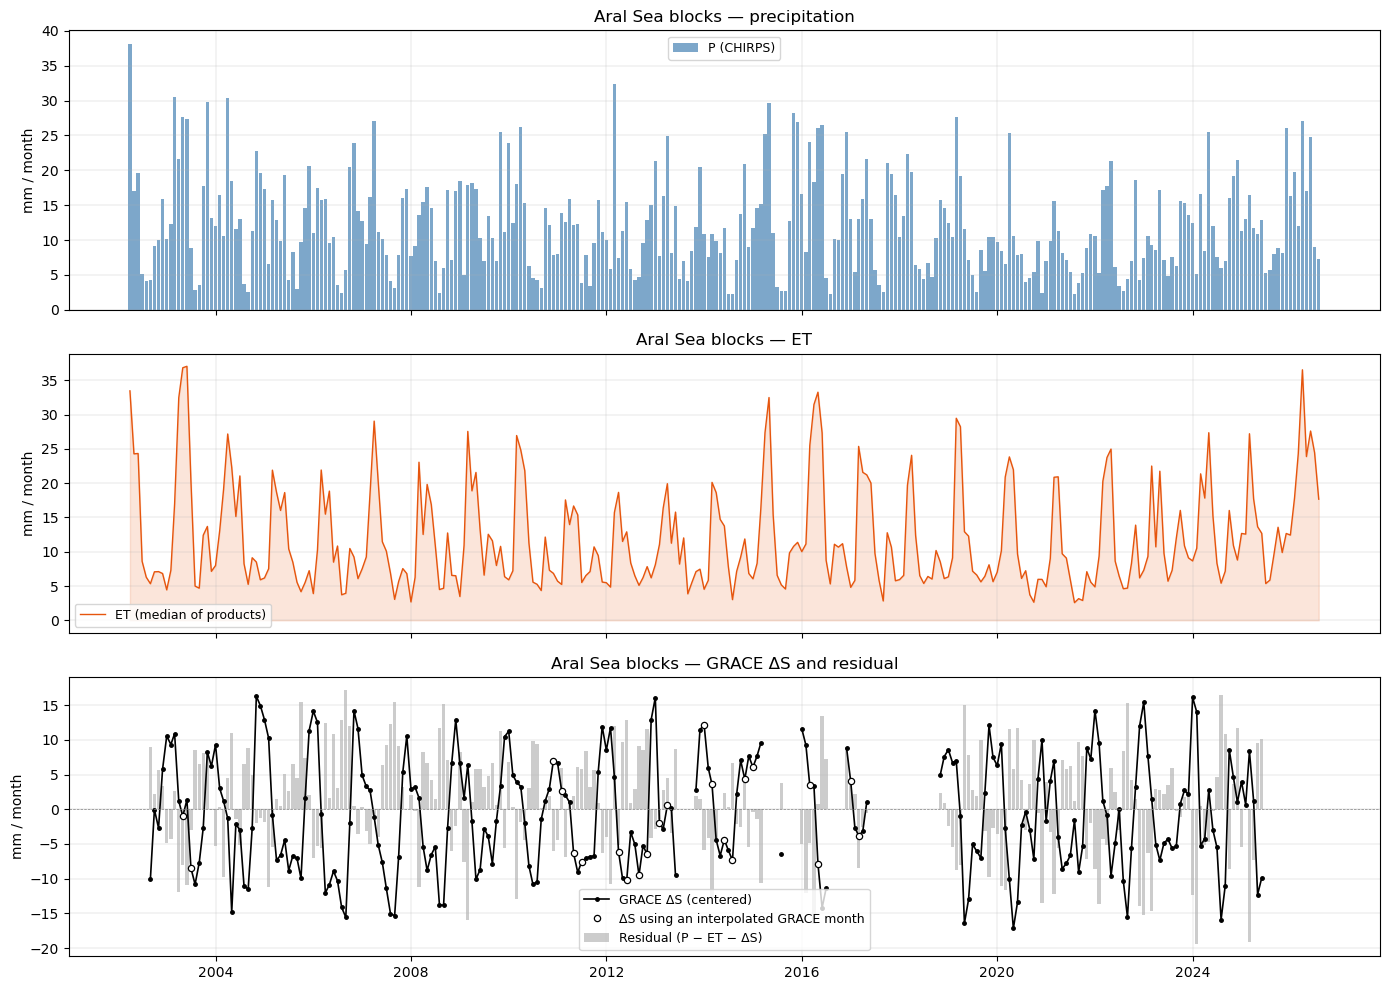

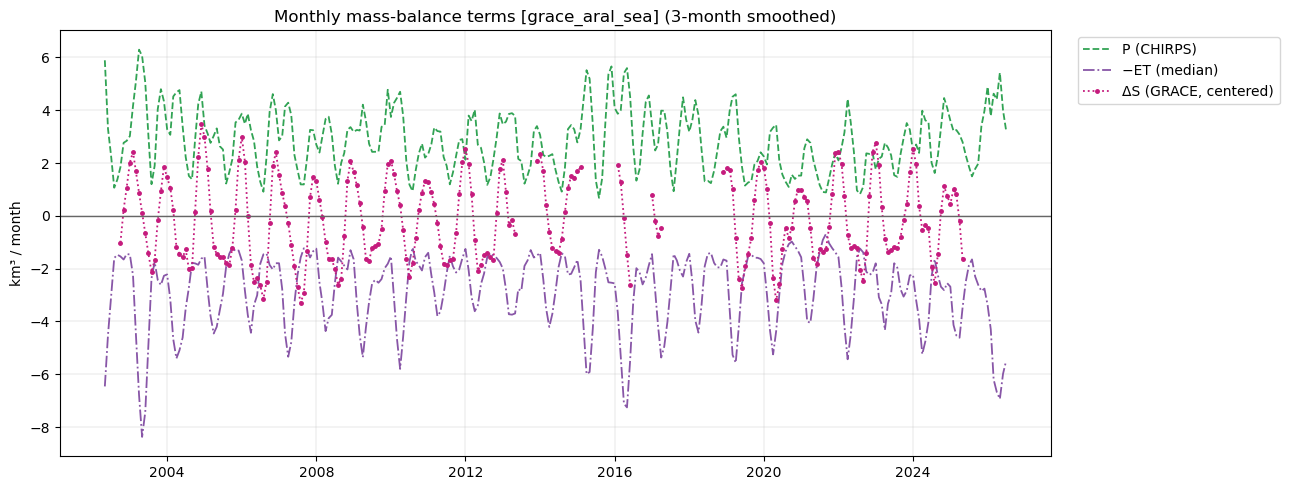

Cumulative residual over 241 closure months: +50.00 km³ (mean +0.207 km³/month)


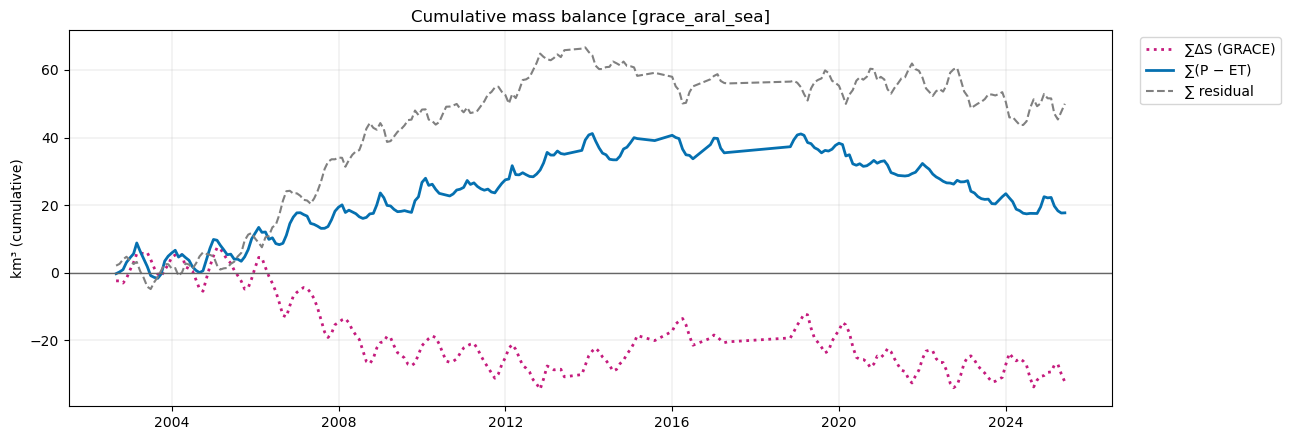

In [9]:
bp.plot_balance_panels(bal, DOMAIN_LABEL, save=FIG_DIR / "mass_balance_panels.png"); plt.show()
bp.plot_terms(bal, f"Monthly mass-balance terms [{GEOM_TAG}]", save=FIG_DIR / "mass_balance_terms.png"); plt.show()
bp.plot_cumulative(bal, f"Cumulative mass balance [{GEOM_TAG}]", save=FIG_DIR / "cumulative_sums.png"); plt.show()

## 9 — Seasonality and summary

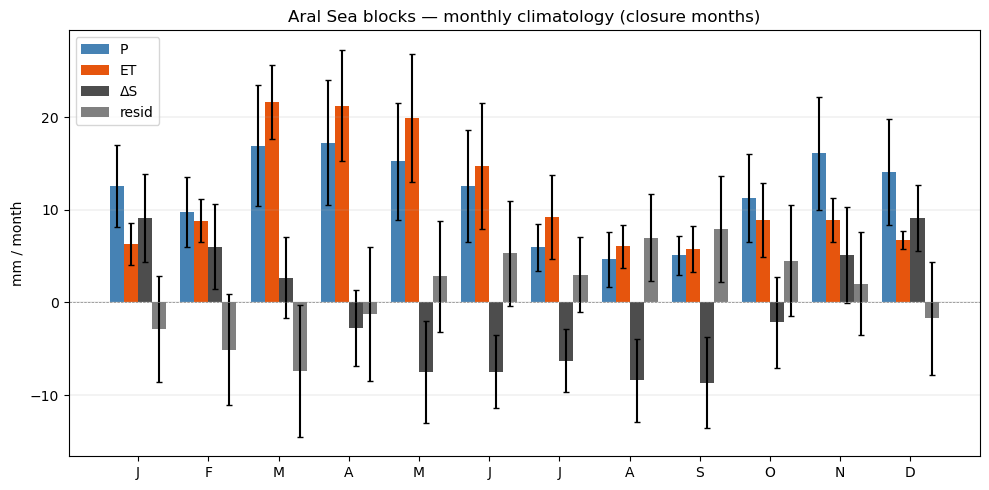

Closure months: 241
  P               +144 mm/yr
  ET              +141 mm/yr
  ΔS                -7 mm/yr
  P − ET − ΔS      +10 mm/yr
Cumulative ΔS over closure months: -32.3 km³
Outputs written to /Users/octaviacrompton/Projects/Okavango-water-balance/figures/ET comparison/grace_aral_sea


In [10]:
clim = monthly_climatology(bal.closure(), {"P_mm": "P", "ET_mm": "ET", "dS_mm": "ΔS", "resid_mm": "resid"})
bp.plot_climatology(clim, ["P", "ET", "ΔS", "resid"], ["steelblue", "#e6550d", "0.3", "grey"],
                    "Aral Sea blocks — monthly climatology (closure months)", save=FIG_DIR / "climatology.png"); plt.show()
d = bal.closure()
print(f"Closure months: {len(d)}")
for c, lab in [("P_mm", "P"), ("ET_mm", "ET"), ("dS_mm", "ΔS"), ("resid_mm", "P − ET − ΔS")]:
    print(f"  {lab:12s} {d[c].mean() * 12:+7.0f} mm/yr")
print(f"Cumulative ΔS over closure months: {d['dS_km3'].sum():+.1f} km³")
write_outputs(bal, FIG_DIR, GEOM_TAG, USE_BLOCKS)